In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'  # ganti '-1' kalau OOM

import re
import numpy as np
import pandas as pd
from nltk.corpus import stopwords
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import load_model
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# CONFIG
# ============================================================
TRAIN_CSV    = 'youtube_enriched_cluster.csv'
TEST_CSV     = 'generalization_labeled.csv'
MODEL_PATH   = 'final_multimodal_model.h5'
THUMB_DIR    = 'thumbnails_generalization'
OUTPUT_CSV   = 'generalization_results.csv'

MAX_NUM_WORDS  = 10000
MAX_SEQ_LENGTH = 15
IMG_SIZE       = (224, 224)
CLASS_ORDER    = ['rendah', 'sedang', 'tinggi']

In [2]:
# ============================================================
# STEP 1 — Rebuild tokenizer dari training data
# ============================================================
print("📂 Rebuilding tokenizer from training data...")
train_df   = pd.read_csv(TRAIN_CSV)
stop_words = set(stopwords.words('indonesian'))

def clean_text(text):
    if pd.isna(text): return ""
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = ' '.join([w for w in text.split() if w not in stop_words and len(w) > 1])
    return text

train_df['clean_title'] = train_df['Title'].apply(clean_text)
train_df = train_df[train_df['clean_title'].str.len() > 0]

tokenizer = Tokenizer(num_words=MAX_NUM_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['clean_title'])
print(f"✅ Tokenizer rebuilt — vocab size: {len(tokenizer.word_index)}")

# ============================================================
# STEP 2 — Load & preprocess generalization test data
# ============================================================
print("\n📂 Loading generalization data...")
test_df = pd.read_csv(TEST_CSV)
test_df = test_df[test_df['performa'].notna()].copy()
test_df['clean_title'] = test_df['Title'].apply(clean_text)
test_df = test_df[test_df['clean_title'].str.len() > 0].copy()

# Filter yang ada thumbnail
def thumb_exists(path):
    return os.path.exists(str(path)) if path else False

test_df = test_df[test_df['thumbnail_path'].apply(thumb_exists)].reset_index(drop=True)
print(f"✅ Test samples: {len(test_df)}")
print(f"\n📊 Distribusi per channel:")
print(test_df.groupby(['channel', 'performa']).size().unstack(fill_value=0))

# Encode label
le = LabelEncoder()
le.fit(CLASS_ORDER)
test_df['performa_encoded'] = le.transform(test_df['performa'])

# Tokenize title
test_padded = pad_sequences(
    tokenizer.texts_to_sequences(test_df['clean_title']),
    maxlen=MAX_SEQ_LENGTH, padding='post'
)

📂 Rebuilding tokenizer from training data...
✅ Tokenizer rebuilt — vocab size: 2820

📂 Loading generalization data...
✅ Test samples: 150

📊 Distribusi per channel:
performa                   rendah  sedang
channel                                  
CNN Indonesia                  19      31
Curhat Bang Denny Sumargo      18      32
Helmy Yahya Bicara             21      29


In [3]:
# ============================================================
# STEP 3 — Load model
# ============================================================
print(f"\n🔧 Loading model...")
model = load_model(MODEL_PATH)
print("✅ Model loaded")

# ============================================================
# STEP 4 — Load images & predict
# ============================================================
print("\n🖼️  Loading thumbnails...")
images, valid_idx = [], []
for i, row in test_df.iterrows():
    path = row['thumbnail_path']
    img  = load_img(path, target_size=IMG_SIZE)
    images.append(img_to_array(img) / 255.0)
    valid_idx.append(i)

images_array  = np.array(images)
text_array    = test_padded[valid_idx]
true_labels   = test_df.loc[valid_idx, 'performa_encoded'].values
test_df_valid = test_df.loc[valid_idx].reset_index(drop=True)

print("🔮 Predicting...")
preds        = model.predict({'image_input': images_array, 'text_input': text_array},
                              batch_size=16, verbose=1)
pred_classes = np.argmax(preds, axis=1)
pred_labels  = le.inverse_transform(pred_classes)
true_labels_str = le.inverse_transform(true_labels)




🔧 Loading model...
✅ Model loaded

🖼️  Loading thumbnails...
🔮 Predicting...
10/10 [==============================] - 3s 10ms/step



📊 GENERALIZATION TEST — CLASSIFICATION REPORT
              precision    recall  f1-score   support

      rendah       1.00      0.76      0.86        58
      sedang       0.90      0.96      0.93        92
      tinggi       0.00      0.00      0.00         0

    accuracy                           0.88       150
   macro avg       0.63      0.57      0.60       150
weighted avg       0.94      0.88      0.90       150



C:\Users\LENOVO\anaconda3\envs\tf-gpu-clean\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\LENOVO\anaconda3\envs\tf-gpu-clean\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\LENOVO\anaconda3\envs\tf-gpu-clean\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


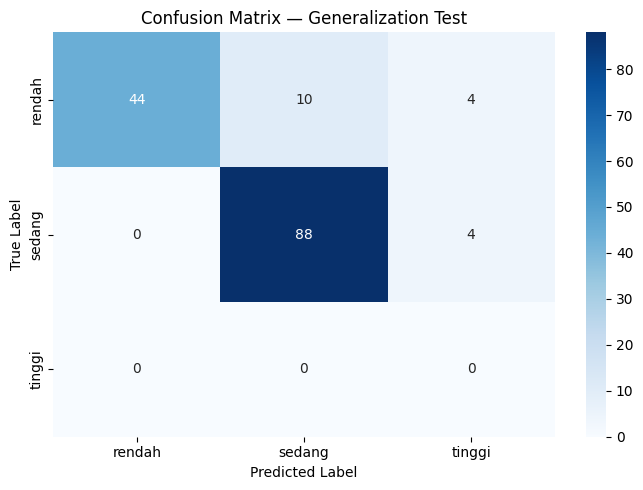

✅ Saved → 'confusion_matrix_generalization.png'

🎯 Overall Accuracy: 0.8800 (88.00%)

📊 Accuracy per channel:
channel
CNN Indonesia                0.64
Curhat Bang Denny Sumargo    1.00
Helmy Yahya Bicara           1.00

✅ Hasil disimpan → 'generalization_results.csv'


In [4]:
# ============================================================
# STEP 5 — Evaluasi
# ============================================================
print("\n" + "="*55)
print("📊 GENERALIZATION TEST — CLASSIFICATION REPORT")
print("="*55)
print(classification_report(true_labels_str, pred_labels, target_names=CLASS_ORDER))

# Confusion Matrix
cm = confusion_matrix(true_labels_str, pred_labels, labels=CLASS_ORDER)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER)
plt.title('Confusion Matrix — Generalization Test')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix_generalization.png', dpi=150)
plt.show()
print("✅ Saved → 'confusion_matrix_generalization.png'")

accuracy = np.mean(pred_classes == true_labels)
print(f"\n🎯 Overall Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Per channel breakdown
test_df_valid['predicted'] = pred_labels
test_df_valid['true']      = true_labels_str
test_df_valid['correct']   = test_df_valid['predicted'] == test_df_valid['true']

print("\n📊 Accuracy per channel:")
print(test_df_valid.groupby('channel')['correct'].mean().round(3).to_string())

# ============================================================
# STEP 6 — Save hasil
# ============================================================
test_df_valid.to_csv(OUTPUT_CSV, index=False)
print(f"\n✅ Hasil disimpan → '{OUTPUT_CSV}'")